In [1]:
import numpy as np
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
import dask.array as da
import dask_image.imread
import cv2
import nibabel as nib
from ultralytics import YOLO

In [2]:
in_dir = '/Users/KARATB01/bigpurple_data/micmac'
# CONSIDER TRYING TO DO GLOBAL THRESHOLDING AGAIN, BUT TAKING IMAGE CENTER AND THEN SOME SQUARE FROM THERE TO CALCULATE GLOBAL

#img = nib.load(f'/Users/KARATB01/bigpurple_scratch/micmac/histo_volumes/MicrogliaBlock200um_no-optical.mnc')
#affine_direct = img.affine
aa = 0

img = nib.load(f'{in_dir}/microglia_2um_nissl_aligned_images/41759_G_095.mnc')
affine = img.affine
hdr = img.header
img = img.get_fdata()
#img = da.from_array(img)

#img = dask_image.imread.imread(f'{in_dir}/{filenames[aa]}')
img = np.squeeze(img[:,:,:])

boxsize = [1000,1000]

binx = int(np.round(img.shape[0] / boxsize[0])) # 299 x 299 bins
biny = int(np.round(img.shape[1] / boxsize[1]))

#gray_image = cv2.cvtColor(img.compute(), cv2.COLOR_RGB2GRAY)
gray_image = img / np.max(img)
gray_image = gray_image * 255

mask = gray_image>5

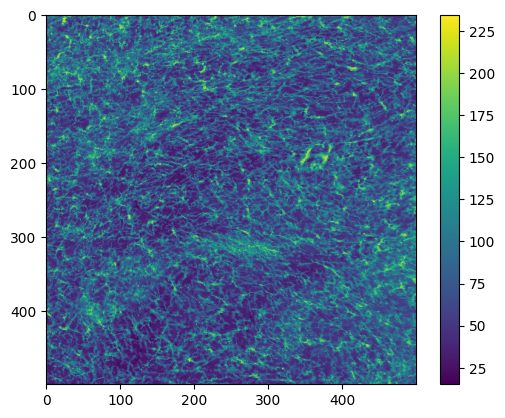

In [3]:
plt.imshow(gray_image[10000:10500,10000:10500])
plt.colorbar()

In [5]:
from tifffile import TiffWriter

with TiffWriter(f'{in_dir}/test_micro_sam.tiff', bigtiff=True) as tif:
    tif.write(gray_image[10000:10500,10000:10500])

In [21]:
model = YOLO("yolo11m-seg.pt")
color_img = cv2.cvtColor(gray_image[10000:15000,10000:15000].astype(np.uint8), cv2.COLOR_GRAY2BGR)


results = model(color_img)


WARNING ⚠️ Download failure, retrying 1/3 https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11m-seg.pt... <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)>


######################################################################## 100.0%



0: 640x640 (no detections), 118.4ms
Speed: 2.0ms preprocess, 118.4ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


In [12]:
import cv2
import numpy as np
from ultralytics import YOLO

# 1. Load the model
model = YOLO("yolo11m-seg.pt")

# 2. Get your raw slice (example 5000x5000)
slice_2d = gray_image[10000:10500,10000:10500]

# 3. Normalize float64 strictly to uint8 (0-255)
img_min, img_max = slice_2d.min(), slice_2d.max()
if img_max - img_min > 0:
    normalized = 255.0 * (slice_2d - img_min) / (img_max - img_min)
else:
    normalized = np.zeros_like(slice_2d)
uint8_img = normalized.astype(np.uint8)
color_img = np.stack([uint8_img] * 3, axis=-1)

# 4. Use Sliced Inference to loop over micro-patches
results = model.predict(
    source=color_img,
    conf=0.01,           # CRITICAL: Drop confidence low enough to accept unfamiliar shapes
    iou=0.3,            # Tighten overlap limits to prevent duplicate masks
    imgsz=640,          # Internal resolution per slice window
    agnostic_nms=True   # Ignore what "class" it thinks it is
)

# 5. Extract thousands of agnostic masks
for result in results:
    if result.masks is not None:
        # Array shape: [Num_Of_Cells, Height, Width]
        all_cell_masks = result.masks.data.cpu().numpy()
        print(f"Success! Extracted {len(all_cell_masks)} individual masks.")


0: 640x640 (no detections), 110.3ms
Speed: 1.1ms preprocess, 110.3ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


In [9]:
import cv2
import numpy as np
from ultralytics import YOLO

# 1. Initialize the correct segmentation model (Auto-downloads)
model = YOLO("yolo11m-seg.pt")

# 2. Slice your raw float64 array
slice_2d =gray_image[10000:10500,10000:10500]

# 3. Normalize to full uint8 spectrum to prevent blank slices
img_min, img_max = slice_2d.min(), slice_2d.max()
if img_max - img_min > 0:
    normalized = 255.0 * (slice_2d - img_min) / (img_max - img_min)
else:
    normalized = np.zeros_like(slice_2d)

uint8_img = normalized.astype(np.uint8)

# 4. Convert single channel array to 3 channels for YOLO
color_img = np.stack([uint8_img] * 3, axis=-1)

# 5. Run inference (imgsz=1024 keeps high resolution without crashing VRAM)
results = model(color_img, imgsz=1024)

# 6. Extract the results
for result in results:
    if result.masks is not None:
        # Access the binary masks tensor (0s and 1s per pixel)
        masks = result.masks.data.cpu().numpy()
        print(f"Successfully segmented {len(masks)} cells!")
    
    # Save a visual overlay map of your cells
    result.save(filename="cell_segmentation_output.jpg")


0: 1024x1024 (no detections), 296.6ms
Speed: 2.1ms preprocess, 296.6ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)


In [22]:
results[0].show()

In [14]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [29]:
from cellpose import models

model = models.CellposeModel(model_type="cyto3", gpu=False)


model_type argument is not used in v4.0.1+. Ignoring this argument...


In [34]:
m = model.eval(
    gray_image[10000:10500,10000:10500],
    diameter=None,
    channels=[0,0],
    flow_threshold=0.4,
    cellprob_threshold=0.95,
)

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


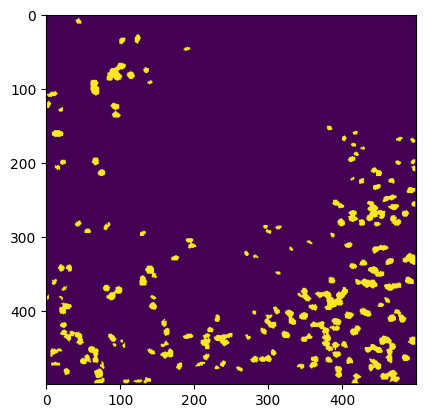

In [35]:
plt.imshow(m[0]>0)

In [37]:
from micro_sam.automatic_segmentation import get_predictor_and_segmenter, automatic_instance_segmentation


/Users/KARATB01/venv_all/lib/python3.13/site-packages/torch_em/util/image.py:6: UserWarning: elf has switched from the affogato, vigra, and nifty librares to https://github.com/computational-cell-analytics/bioimage-cpp as new backed for custom functionality implemented in C++, e.g. mutex watershed, multicut etc. This may lead to some changes in behavior and interface. If you run into issues with the new version consider installing a version < 0.9. Please also consider raising an issue on github so that we are aware of issues with the migration.
  from elf.io import open_file
/Users/KARATB01/venv_all/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [40]:
# Load the Segment Anything for Microscopy model.
predictor, segmenter = get_predictor_and_segmenter(model_type="vit_b_lm")

Using apple MPS device.


100%|████████████████████████████████████████| 375M/375M [00:00<00:00, 201GB/s]
100%|█████████████████████████████████████| 38.4M/38.4M [00:00<00:00, 18.2GB/s]


In [41]:
# Run automatic instance segmentation (AIS) on our image.
instances = automatic_instance_segmentation(
    predictor=predictor,
    segmenter=segmenter,
    input_path=gray_image[10000:10100,10000:10100],
)


Initialize instance segmentation with decoder: 100%|██████████| 1/1 [00:01<00:00,  1.70s/it]


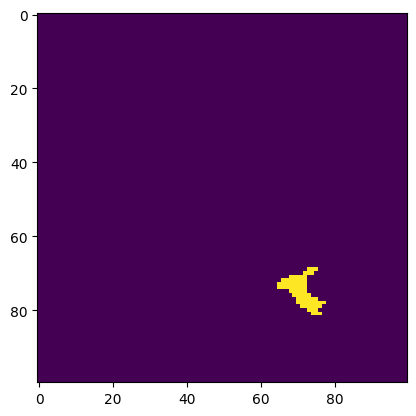

In [43]:
plt.imshow(instances>0)